In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
plt.rcParams.update({'font.size': 16})

def forward(x, W, P, Wc, c):
#     print((W@x).shape)
#     print(Wc[:, c][None].T.repeat(1,6).shape)
    states = torch.concatenate((W @ x, Wc[:, c][None].T.repeat(1,6)), dim=0)
    output = (P @ states)
    return output


def fig_MDS(W1, W2, P, Wc, scale, plot=True):
    list1_length = list2_length = 6
    data = torch.eye(list1_length)
    output1 = forward(data, W1, P, Wc, 0)
    output2 = forward(data, W2, P, Wc, 1)

    # Combine the tensors
    data = np.hstack((output1, output2))  # Assuming you want the first 5 columns of each

    # Perform MDS
    mds = MDS(n_components=2, random_state=0)
    data_2d = mds.fit_transform(data.T)  # Transpose because MDS expects samples as rows
    data_2d[:, [0, 1]] = data_2d[:, [1, 0]]

    if plot:
        # Plot
        fig, ax = plt.subplots(figsize=(5,5),dpi=50)
        dot_size = 400  # Dot size
        dot_edge_width = 3  # Make the dot border thick

        # Plot the lines with a lower zorder
        for i in range(1, list1_length):
            ax.plot(data_2d[i-1:i+1, 0], data_2d[i-1:i+1, 1], color='tab:blue', linewidth=2, zorder=1)
        for i in range(list1_length+1, list1_length+list2_length):
            ax.plot(data_2d[i-1:i+1, 0], data_2d[i-1:i+1, 1], color='tab:orange', linewidth=2, zorder=1)

        # Plot the dots and text with a higher zorder
        for i, point in enumerate(data_2d[:list1_length, :]):
            ax.scatter(point[0], point[1], s=dot_size, edgecolor='tab:blue', facecolor='white', linewidth=dot_edge_width, zorder=2)
            ax.text(point[0], point[1], str(i+1), color='tab:blue', ha='center', va='center', fontweight='bold', zorder=3)

        for i, point in enumerate(data_2d[list1_length:, :]):
            ax.scatter(point[0], point[1], s=dot_size, edgecolor='tab:orange', facecolor='white', linewidth=dot_edge_width, zorder=2)
            ax.text(point[0], point[1], str(i+1), color='tab:orange', ha='center', va='center', fontweight='bold', zorder=3)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
    #     plt.axis('equal')
        ticks = [-scale, scale]

        # Set the same ticks on both axes
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        plt.xlabel('dimension 1')
        plt.ylabel('dimension 2')


        plt.show()
    
        return output1, output2
    else:
        return data_2d.max(), output1, output2


import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
plt.rcParams.update({'font.size': 16})

def plot_heat_map(output1, output2, max_v, plot=True):
    # Correct the labels for the axis to include '6', 'F'
    labels = ['1', '2', '3', '4', '5', '6', '1', '2', '3', '4', '5', '6']

    # Since we added two more labels, we need to regenerate the data and distances
    # Generate random data for 12 points with 100 dimensions
    all_data_corrected = np.concatenate((output1, output2), axis=1)

    # Compute pairwise L2 (Euclidean) distance matrix for the corrected data
    distances_corrected = cdist(all_data_corrected.T, all_data_corrected.T, 'euclidean')

    # Set the distances on the main diagonal to zero for the corrected data
    np.fill_diagonal(distances_corrected, 0)
    if plot:
        # Plotting the heatmap with the corrected settings
        fig, ax = plt.subplots(figsize=(4*1.5, 3*1.5),dpi=50)
        heatmap_corrected = ax.imshow(distances_corrected, cmap='inferno', origin='upper',vmin=0,vmax=max_v)

        # Adding color bar on the side
        cbar = fig.colorbar(heatmap_corrected, ticks=[0, max_v])
        cbar.set_label('L2 distance', rotation=270, labelpad=20)#, labelpad=-20)

        ax.set_xticklabels([])
        ax.set_yticklabels([])

        # Apply custom styling for each label
        for index, label in enumerate(labels):
            if index < 6:  # First 6 indexes
                color = 'tab:blue'
            else:  # Last 6 indexes
                color = 'tab:orange'

            # Set custom x-axis labels
            ax.text(index, 12, label, va='center', ha='center', color=color, fontweight='bold')

            # Set custom y-axis labels (considering the reversed axis)
            ax.text(-1, index, label, va='center', ha='right', color=color, fontweight='bold')



        # Turning off the grid
        ax.grid(False)

        # Show the plot
        plt.show()
        print(distances_corrected.max())
    else:
        return distances_corrected.max()
    


In [2]:
import torch
import numpy as np

def average_cosine(vectors):

    # Normalize each vector
    vectors_norm = vectors / vectors.norm(dim=1, keepdim=True)

    # Compute the cosine similarity matrix (dot product of normalized vectors)
    cosine_similarities = vectors_norm @ vectors_norm.T

    # Extract the upper triangle of the matrix, excluding the diagonal
    num_objects = vectors.shape[0]
    i, j = torch.triu_indices(num_objects, num_objects, offset=1)
    cosine_similarities_upper = cosine_similarities[i, j]
    # Calculate the average cosine similarity
    average_cosine = cosine_similarities_upper.mean().item()

    
    return average_cosine


def gen_W(num_objects, dim, target_cosine):
    # Define ranges
    sparsity_range = (0.002, 0.01)
    # Initialize the vectors tensor with random sparsity
    vectors = torch.zeros((num_objects, dim), dtype=torch.float)
    num_ones = torch.randint(int(sparsity_range[0] * dim), int(sparsity_range[1] * dim + 1), (num_objects,))
    for i in range(num_objects):
        ones_indices = torch.randperm(dim)[:num_ones[i]]
        vectors[i, ones_indices] = 1

    cos = average_cosine(vectors)
    if target_cosine==0 and cos!=0:
        vectors = torch.zeros((num_objects, dim), dtype=torch.float)
        num_ones = torch.randint(int(sparsity_range[0] * dim), int(sparsity_range[1] * dim + 1), (num_objects,))
        for i in range(num_objects):
            ones_indices = torch.randperm(dim)[:num_ones[i]]
            vectors[i, ones_indices] = 1

        cos = average_cosine(vectors)
        

    while(cos<target_cosine):
        # Randomly pick a pair of objects i and j
        indices = torch.randperm(num_objects)[:2]
        i, j = indices[0], indices[1]
        vi = vectors[i, :]
        vj = vectors[j, :]

        # Identify dimensions where only one of them has a 1 using XOR
        diff_indices = torch.nonzero(vi.int() ^ vj.int()).flatten()
        if len(diff_indices) > 0:
            # Randomly pick one such dimension
            dim_to_change = diff_indices[torch.randint(len(diff_indices), (1,)).item()]
        else:
            continue

        # Determine which vector has 0 at the chosen dimension
        if vi[dim_to_change] == 0:
            index_to_modify = i
        else:
            index_to_modify = j

        # Set the value of this object at the chosen dimension to 1
        vectors[index_to_modify, dim_to_change] = 1

        # Find a dimension in the same object that currently equals 1
        ones_indices = torch.nonzero(vectors[index_to_modify] == 1).flatten()
        ones_indices = ones_indices[ones_indices != dim_to_change]  # Exclude the modified dimension

        # Randomly pick one such dimension to set to 0
        dim_to_zero = ones_indices[torch.randint(len(ones_indices), (1,)).item()]
        vectors[index_to_modify, dim_to_zero] = 0

        # Compute the average cosine again
        cos = average_cosine(vectors)
#     print(cos)
    return vectors.T



Training Progress:   0%|          | 0/10 [00:00<?, ?it/s]

Ground truth ranking: [0, 1, 2, 3, 4, 5]
Learned ranking: [0, 1, 2, 3, 4, 5]
Mean v values: [-3.41999054 -2.21997643 -0.69999021  0.60005498  2.04003048  3.46499157]
Ground truth ranking: [0, 1, 2, 3, 4, 5]
Learned ranking: [0, 1, 2, 3, 4, 5]
Mean v values: [-3.31999779 -2.10000896 -0.89998817  0.49999291  1.91999066  3.49999046]
35.125544043748974


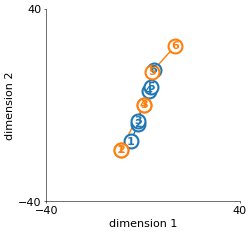

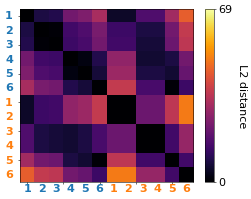

48.99999447555519


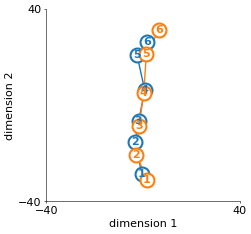

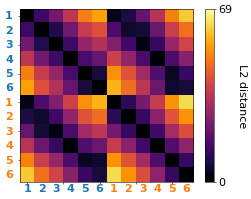

62.966722822104934


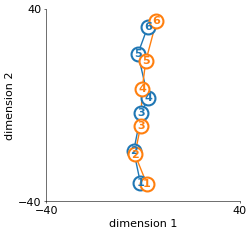

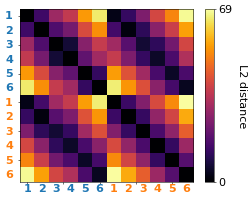

68.48785533825148


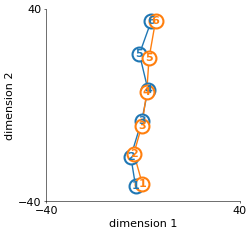

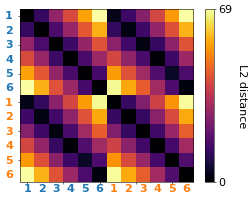

69.22840982669022


In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from sklearn.utils import shuffle

# Define the number of objects and dimensions
num_objects = 6
input_dim = num_objects
context_dim = 2
hidden_dim = 1000
hidden_context_dim = 1000
output_dim = 100

# Ground truth ranking
ground_truth_ranking1 = [0,1,2,3,4,5]
ground_truth_ranking2 = [0,1,2,3,4,5]

# Create all possible pairs of objects
pairs1 = [(i, j) for i in range(num_objects) for j in range(num_objects) if i != j]
labels1 = [(1 if ground_truth_ranking1.index(i) < ground_truth_ranking1.index(j) else -1) for i, j in pairs1]
pairs2 = [(i, j) for i in range(num_objects) for j in range(num_objects) if i != j]
labels2 = [(1 if ground_truth_ranking2.index(i) < ground_truth_ranking2.index(j) else -1) for i, j in pairs2]

# One-hot encode the input
one_hot_vectors1 = torch.eye(num_objects)
one_hot_vectors2 = torch.eye(num_objects)

one_hot_context = torch.eye(context_dim)

# Initialize W (fixed, random)
# W1 = torch.randn(hidden_dim, input_dim)
# W2 = torch.randn(hidden_dim, input_dim)

# Wc = 10.*torch.randn(hidden_context_dim, context_dim) 
cos=0
W1 = gen_W(num_objects, hidden_dim, cos)
W2 = gen_W(num_objects, hidden_dim, cos)
Wc = gen_W(context_dim, hidden_context_dim, cos)

# Initialize P (trainable)
P = torch.randn(output_dim, hidden_dim+hidden_context_dim) * 0.0001

# Learning rate
eta = 0.1

# Number of epochs
num_epochs = 10

# Define the error function
def error_function(v_i, v_j, label):
    error = torch.sign(torch.maximum((label * (v_i - v_j) +1), torch.tensor(0))*label)
    return error

# Track the mean of v for each object over epochs
mean_v_values1 = np.zeros((num_epochs*len(pairs1)+1, num_objects))
mean_v_values2 = np.zeros((num_epochs*len(pairs1)+1, num_objects))

for i in range(num_objects):
    s_i1_s = W1 @ one_hot_vectors1[i]
    s_i1_c = Wc @ one_hot_context[0]
    v_i1 = P @ torch.concatenate((s_i1_s,s_i1_c))
    mean_v_values1[0, i] = v_i1.mean().item()

    s_i2_s = W2 @ one_hot_vectors2[i]
    s_i2_c = Wc @ one_hot_context[1]
    v_i2 = P @ torch.concatenate((s_i2_s,s_i2_c))
    mean_v_values2[0, i] = v_i2.mean().item()
        
# Training loop
errors = []
iters=0
P_record = []
for epoch in tqdm(range(num_epochs), desc="Training Progress"):
    if epoch in [1,3,5,9]:
        P_record += [P.clone()]
    epoch_error = 0
    pairs2, labels2 = shuffle(pairs2, labels2)
    pairs1, labels1 = shuffle(pairs1, labels1)
    for (i1, j1), label1, (i2, j2), label2 in zip(pairs1, labels1, pairs2, labels2):
        #first linear order
        s_i1_s = W1 @ one_hot_vectors1[i1]
        s_j1_s = W1 @ one_hot_vectors1[j1]
        s_i1_c = Wc @ one_hot_context[0]
        s_j1_c = Wc @ one_hot_context[0]
        
        s_i1 = torch.concatenate((s_i1_s,s_i1_c))
        s_j1 = torch.concatenate((s_j1_s,s_i1_c))

        v_i1 = P @ s_i1
        v_j1 = P @ s_j1

        e1 = error_function(v_i1, v_j1, label1)
        epoch_error += e1.mean().item()
        P += eta * torch.outer(e1, (s_j1-s_i1))
        
        #second linear order
        s_i2_s = W2 @ one_hot_vectors2[i2]
        s_j2_s = W2 @ one_hot_vectors2[j2]
        s_i1_c = Wc @ one_hot_context[1]
        s_j1_c = Wc @ one_hot_context[1]
        
        s_i2 = torch.concatenate((s_i2_s,s_i2_c))
        s_j2 = torch.concatenate((s_j2_s,s_i2_c))


        v_i2 = P @ s_i2
        v_j2 = P @ s_j2

        e2 = error_function(v_i2, v_j2, label2)
        epoch_error += e2.mean().item()

        P += eta * torch.outer(e2, (s_j2-s_i2))
        # Compute the mean v values for each object
        for i in range(num_objects):
            s_i1_s = W1 @ one_hot_vectors1[i]
            s_i1_c = Wc @ one_hot_context[0]
            v_i1 = P @ torch.concatenate((s_i1_s,s_i1_c))
            mean_v_values1[iters+1, i] = v_i1.mean().item()

            s_i2_s = W2 @ one_hot_vectors2[i]
            s_i2_c = Wc @ one_hot_context[1]
            v_i2 = P @ torch.concatenate((s_i2_s,s_i2_c))
            mean_v_values2[iters+1, i] = v_i2.mean().item()
        iters+=1

    errors.append(epoch_error / (num_objects*2))



# Print the final results
summed_v_values1 = mean_v_values1[-1, :]
learned_ranking1 = sorted(range(num_objects), key=lambda i: summed_v_values1[i])

summed_v_values2 = mean_v_values2[-1, :]
learned_ranking2 = sorted(range(num_objects), key=lambda i: summed_v_values2[i])

print(f"Ground truth ranking: {ground_truth_ranking1}")
print(f"Learned ranking: {learned_ranking1}")
print(f"Mean v values: {summed_v_values1}")

print(f"Ground truth ranking: {ground_truth_ranking2}")
print(f"Learned ranking: {learned_ranking2}")
print(f"Mean v values: {summed_v_values2}")
max_mds = 0
max_heat = 0 
for P in P_record:
    _mds,output1, output2 = fig_MDS(W1, W2, P, Wc, 10, False)
    if _mds>max_mds:
        max_mds = _mds
    _heat = plot_heat_map(output1, output2, 99, False)
    if _heat>max_heat:
        max_heat = _heat
print(max_mds)
for P in P_record:
    output1, output2 = fig_MDS(W1, W2, P, Wc, round(max_mds, -1))
    plot_heat_map(output1, output2, round(max_heat, 0))

Training Progress:   0%|          | 0/21 [00:00<?, ?it/s]

Ground truth ranking: [0, 1, 2, 3, 4, 5]
Learned ranking: [0, 1, 2, 3, 4, 5]
Mean v values: [-4.70159054 -3.50157595 -1.98159027 -0.68154502  0.75843048  0.90179282]
Ground truth ranking: [0, 1, 2, 3, 4, 5]
Learned ranking: [1, 2, 0, 3, 4, 5]
Mean v values: [2.23360157 0.89039093 2.09041166 3.49039268 5.33759117 6.49038982]
69.22840982669022
72.22722198615138
75.22612877089293
78.22511953694423
81.22418468578432
84.22331599880397
87.22250806761446
90.22175336265983
93.2210473912276
96.22038492831051
99.21976268954666
102.21917706876528
105.21862549724464
108.21810405546174
111.21761031900728
111.94569629541735
111.94569629541735
111.94569629541735
111.94569629541735
111.94569629541735
max: 111.94569629541735


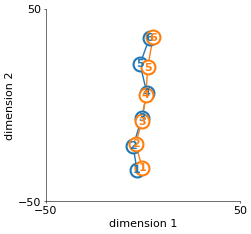

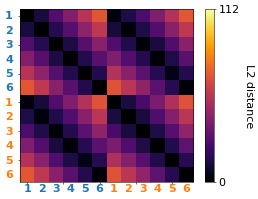

69.22840982669022


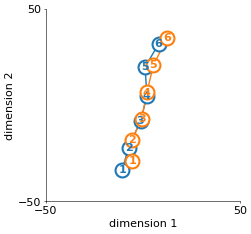

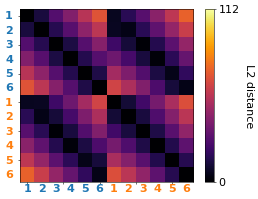

72.22722198615138


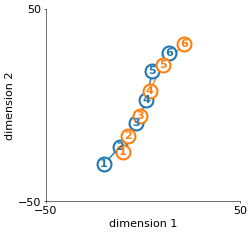

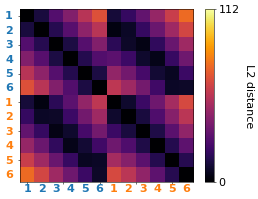

75.22612877089293


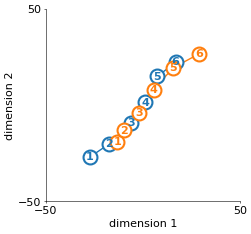

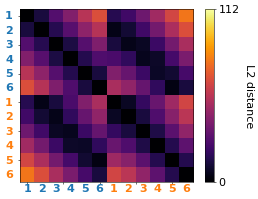

78.22511953694423


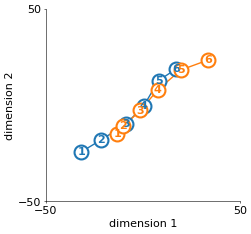

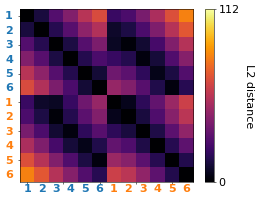

81.22418468578432


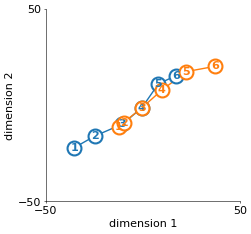

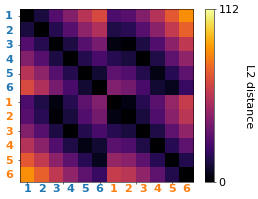

84.22331599880397


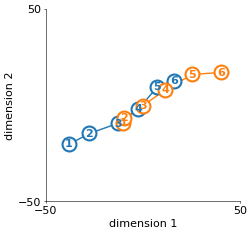

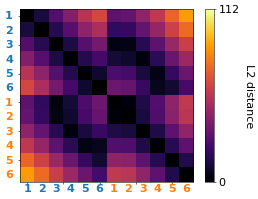

87.22250806761446


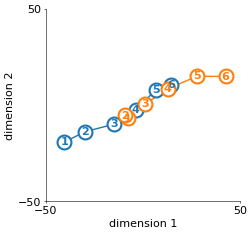

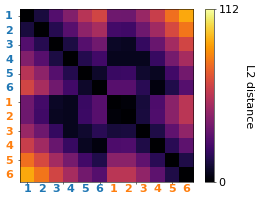

90.22175336265983


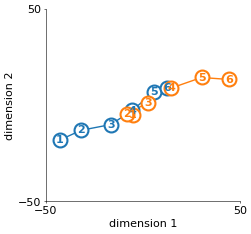

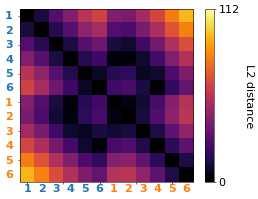

93.2210473912276


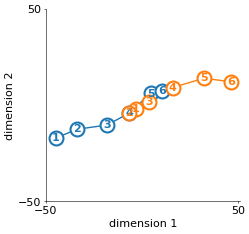

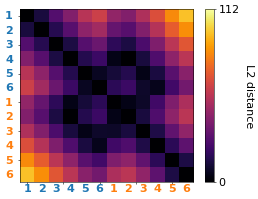

96.22038492831051


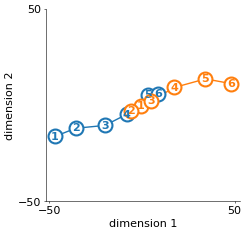

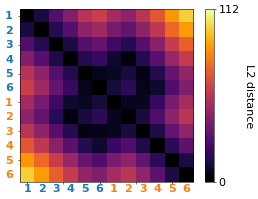

99.21976268954666


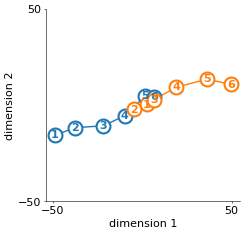

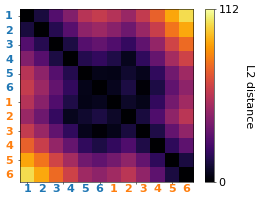

102.21917706876528


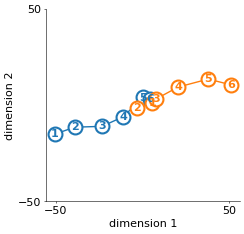

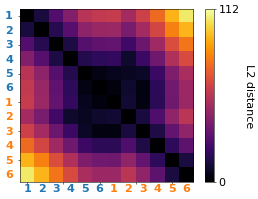

105.21862549724464


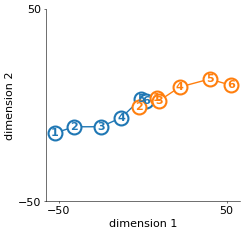

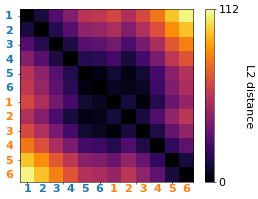

108.21810405546174


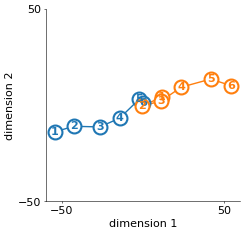

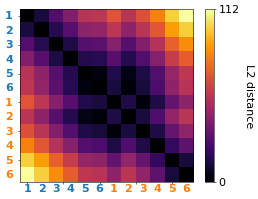

111.21761031900728


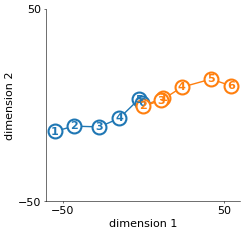

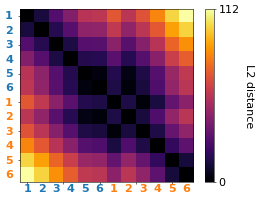

111.94569629541735


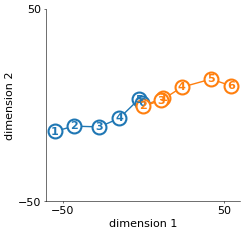

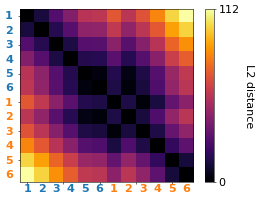

111.94569629541735


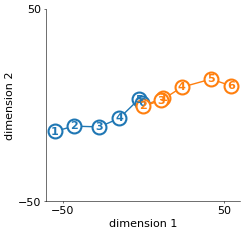

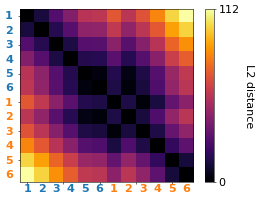

111.94569629541735


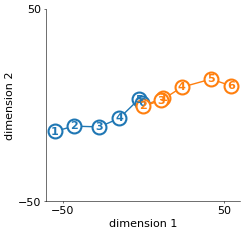

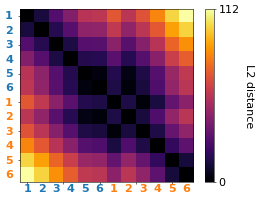

111.94569629541735


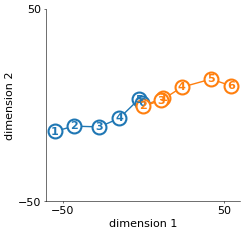

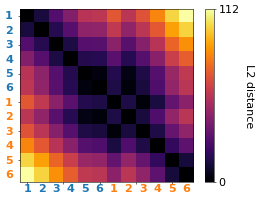

111.94569629541735


In [4]:
from sklearn.utils import shuffle

# virtual training: pair2, labels2
# boundary training: order1[5], order2[0], label=1
num_epochs = 20
eta = 0.03
values_all = np.zeros((num_epochs+1, num_objects*2))
iters=0

# Track the mean of v for each object over epochs
mean_v_values1 = np.zeros((num_epochs+2, num_objects))
mean_v_values2 = np.zeros((num_epochs+2, num_objects))

for i in range(num_objects):
    s_i1_s = W1 @ one_hot_vectors1[i]
    s_i1_c = Wc @ one_hot_context[0]
    s_i1 = torch.concatenate((s_i1_s,s_i1_c))
    v_i1 = P @ s_i1
    mean_v_values1[0, i] = v_i1.mean().item()

    s_i2_s = W2 @ one_hot_vectors2[i]
    s_i2_c = Wc @ one_hot_context[1]
    s_i2 = torch.concatenate((s_i2_s,s_i2_c))
    v_i2 = P @ s_i2
    mean_v_values2[0, i] = v_i2.mean().item()
    
pairs2, labels2 = shuffle(pairs2, labels2)
P_record = []
for epoch in tqdm(range(num_epochs+1), desc="Training Progress"):

    P_record += [P.clone()]
        
    for context in range(2):
        for obj in range(6):
            if context == 0:
                values_all[iters, obj] = \
                (P@torch.concatenate((W1 @ one_hot_vectors1[obj], Wc @ one_hot_context[0]))).mean()
            else:
                values_all[iters, obj+num_objects] = \
                (P@torch.concatenate((W2 @ one_hot_vectors2[obj], Wc @ one_hot_context[1]))).mean()
                

    #boundary training
    s_boundary_low = torch.concatenate((W1 @ one_hot_vectors1[-1], Wc @ one_hot_context[0]))
    s_new = torch.concatenate((W2 @ one_hot_vectors2[0], Wc @ one_hot_context[1]))

    v_boundary_low = P @ s_boundary_low
    v_new = P @ s_new

    e_boundary = error_function(v_boundary_low, v_new, 1)
    epoch_error += e_boundary.mean().item()
    P_pre = P.clone()
    
    context_learning_rate_ratio = 1
    P[:,:hidden_dim] += eta * torch.outer(e_boundary, (s_new-s_boundary_low)[:hidden_dim])
    P[:,hidden_dim:] += context_learning_rate_ratio * eta * torch.outer(e_boundary, (s_new-s_boundary_low)[hidden_dim:])

    
    iters += 1
    for i in range(num_objects):
        s_i1_s = W1 @ one_hot_vectors1[i]
        s_i1_c = Wc @ one_hot_context[0]
        s_i1 = torch.concatenate((s_i1_s,s_i1_c))
        v_i1 = P @ s_i1
        mean_v_values1[epoch+1, i] = v_i1.mean().item()

        s_i2_s = W2 @ one_hot_vectors2[i]
        s_i2_c = Wc @ one_hot_context[1]
        s_i2 = torch.concatenate((s_i2_s,s_i2_c))
        v_i2 = P @ s_i2
        mean_v_values2[epoch+1, i] = v_i2.mean().item()
summed_v_values1 = mean_v_values1[-1, :]
learned_ranking1 = sorted(range(num_objects), key=lambda i: summed_v_values1[i])

summed_v_values2 = mean_v_values2[-1, :]
learned_ranking2 = sorted(range(num_objects), key=lambda i: summed_v_values2[i])

print(f"Ground truth ranking: {ground_truth_ranking1}")
print(f"Learned ranking: {learned_ranking1}")
print(f"Mean v values: {summed_v_values1}")

print(f"Ground truth ranking: {ground_truth_ranking2}")
print(f"Learned ranking: {learned_ranking2}")
print(f"Mean v values: {summed_v_values2}")
max_mds = 0
max_heat = 0
for i in range(num_epochs):
    P = P_record[i]
    _mds,output1, output2 = fig_MDS(W1, W2, P, Wc, 10, False)
    if _mds>max_mds:
        max_mds = _mds
    _heat = plot_heat_map(output1, output2, 99, False)
    print(_heat)
    if _heat>max_heat:
        max_heat = _heat
print('max:', max_heat)
for i in range(num_epochs):
    P = P_record[i]
    output1, output2 = fig_MDS(W1, W2, P, Wc, round(max_mds, -1))
    max_c = plot_heat_map(output1, output2, round(max_heat, 0))

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from tqdm.notebook import tqdm
# -------------------------
# Utils: W generator (same as yours)
# -------------------------
def average_cosine(vectors: torch.Tensor) -> float:
    vectors_norm = vectors / vectors.norm(dim=1, keepdim=True)
    cosine_similarities = vectors_norm @ vectors_norm.T
    n = vectors.shape[0]
    i, j = torch.triu_indices(n, n, offset=1)
    return cosine_similarities[i, j].mean().item()

def gen_W(num_objects: int, dim: int, target_cosine: float) -> torch.Tensor:
    sparsity_range = (0.002, 0.01)
    vectors = torch.zeros((num_objects, dim), dtype=torch.float)
    num_ones = torch.randint(int(sparsity_range[0] * dim), int(sparsity_range[1] * dim + 1), (num_objects,))
    for i in range(num_objects):
        ones_indices = torch.randperm(dim)[:num_ones[i]]
        vectors[i, ones_indices] = 1

    cos = average_cosine(vectors)
    if target_cosine == 0 and cos != 0:
        vectors = torch.zeros((num_objects, dim), dtype=torch.float)
        num_ones = torch.randint(int(sparsity_range[0] * dim), int(sparsity_range[1] * dim + 1), (num_objects,))
        for i in range(num_objects):
            ones_indices = torch.randperm(dim)[:num_ones[i]]
            vectors[i, ones_indices] = 1
        cos = average_cosine(vectors)

    while cos < target_cosine:
        indices = torch.randperm(num_objects)[:2]
        i, j = indices[0], indices[1]
        vi = vectors[i, :]
        vj = vectors[j, :]
        diff_indices = torch.nonzero(vi.int() ^ vj.int()).flatten()
        if len(diff_indices) == 0:
            continue
        dim_to_change = diff_indices[torch.randint(len(diff_indices), (1,)).item()]
        index_to_modify = i if vi[dim_to_change] == 0 else j

        vectors[index_to_modify, dim_to_change] = 1
        ones_indices = torch.nonzero(vectors[index_to_modify] == 1).flatten()
        ones_indices = ones_indices[ones_indices != dim_to_change]
        dim_to_zero = ones_indices[torch.randint(len(ones_indices), (1,)).item()]
        vectors[index_to_modify, dim_to_zero] = 0

        cos = average_cosine(vectors)

    return vectors.T  # (dim, num_objects)

# -------------------------
# Core pieces
# -------------------------
def error_function(v_i: torch.Tensor, v_j: torch.Tensor, label: int) -> torch.Tensor:
    lbl = torch.tensor(label, dtype=v_i.dtype, device=v_i.device)
    margin = lbl * (v_i - v_j) + 1.0
    hinge = torch.maximum(margin, torch.tensor(0.0, dtype=v_i.dtype, device=v_i.device))
    return torch.sign(hinge * lbl)

def mean_v_per_item(W_item, Wc, P, c_idx, one_hot_vectors, one_hot_context):
    s_s = W_item @ one_hot_vectors.T  # (hidden_dim, num_objects)
    s_c = (Wc @ one_hot_context[c_idx]).unsqueeze(1).repeat(1, one_hot_vectors.shape[0])  # (hidden_context_dim, num_objects)
    states = torch.concatenate((s_s, s_c), dim=0)
    v = P @ states  # (output_dim, num_objects)
    return v.mean(dim=0)  # (num_objects,)

# -------------------------
# Phase 1 training (keep same learning logic)
# -------------------------
def train_short_phase(
    W1, W2, Wc, P,
    pairs1, labels1, pairs2, labels2,
    one_hot_vectors1, one_hot_vectors2, one_hot_context,
    eta: float, num_epochs: int
):
    for _ in range(num_epochs):
        pairs1_s, labels1_s = shuffle(pairs1, labels1)
        pairs2_s, labels2_s = shuffle(pairs2, labels2)
        for (i1, j1), label1, (i2, j2), label2 in zip(pairs1_s, labels1_s, pairs2_s, labels2_s):
            # context 0
            s_i1_s = W1 @ one_hot_vectors1[i1]
            s_j1_s = W1 @ one_hot_vectors1[j1]
            s_c0 = Wc @ one_hot_context[0]
            s_i1 = torch.concatenate((s_i1_s, s_c0))
            s_j1 = torch.concatenate((s_j1_s, s_c0))
            v_i1 = P @ s_i1
            v_j1 = P @ s_j1
            e1 = error_function(v_i1, v_j1, int(label1))
            P += eta * torch.outer(e1, (s_j1 - s_i1))

            # context 1
            s_i2_s = W2 @ one_hot_vectors2[i2]
            s_j2_s = W2 @ one_hot_vectors2[j2]
            s_c1 = Wc @ one_hot_context[1]
            s_i2 = torch.concatenate((s_i2_s, s_c1))
            s_j2 = torch.concatenate((s_j2_s, s_c1))
            v_i2 = P @ s_i2
            v_j2 = P @ s_j2
            e2 = error_function(v_i2, v_j2, int(label2))
            P += eta * torch.outer(e2, (s_j2 - s_i2))

    return P

# -------------------------
# Phase 2 training (train long) using YOUR update rule
# -------------------------
def train_long_phase_boundary_Psplit(
    W1, W2, Wc, P,
    boundary_low_ctx0: int, boundary_high_ctx1: int, boundary_label: int,
    one_hot_vectors1, one_hot_vectors2, one_hot_context,
    eta: float, context_learning_rate_ratio: float,
    num_steps: int
):
    hidden_dim = W1.shape[0]

    for _ in range(num_steps):
        # boundary_low: ctx0 item
        s_low_s = W1 @ one_hot_vectors1[boundary_low_ctx0]
        s_low_c = Wc @ one_hot_context[0]
        s_boundary_low = torch.concatenate((s_low_s, s_low_c))

        # new: ctx1 item
        s_new_s = W2 @ one_hot_vectors2[boundary_high_ctx1]
        s_new_c = Wc @ one_hot_context[1]
        s_new = torch.concatenate((s_new_s, s_new_c))

        v_low = P @ s_boundary_low
        v_new = P @ s_new

        e_boundary = error_function(v_low, v_new, int(boundary_label))

        delta = (s_new - s_boundary_low)
        P[:, :hidden_dim] += eta * torch.outer(e_boundary, delta[:hidden_dim])
        P[:, hidden_dim:] += (context_learning_rate_ratio * eta) * torch.outer(e_boundary, delta[hidden_dim:])

    return P

# -------------------------
# Success + debug print
# -------------------------
def check_and_print_run(
    W1, W2, Wc, P,
    ground_truth_ranking,
    one_hot_vectors1, one_hot_vectors2, one_hot_context,
    boundary_low_ctx0: int, boundary_high_ctx1: int,
    ratio: float, rep: int
) -> bool:
    with torch.no_grad():
        v1 = mean_v_per_item(W1, Wc, P, 0, one_hot_vectors1, one_hot_context).cpu().numpy()
        v2 = mean_v_per_item(W2, Wc, P, 1, one_hot_vectors2, one_hot_context).cpu().numpy()

    learned1 = list(np.argsort(v1))
    learned2 = list(np.argsort(v2))

    ok_within = (learned1 == ground_truth_ranking) and (learned2 == ground_truth_ranking)
    ok_boundary = (v1[boundary_low_ctx0] < v2[boundary_high_ctx1])
    ok = bool(ok_within and ok_boundary)

#     print(
#         f"ratio={ratio:.2f} rep={rep:02d} "
#         f"rank_ctx0={learned1} rank_ctx1={learned2} "
#         f"boundary: v1[{boundary_low_ctx0}]={v1[boundary_low_ctx0]:.4f}  v2[{boundary_high_ctx1}]={v2[boundary_high_ctx1]:.4f} "
#         f"ok_within={ok_within} ok_boundary={ok_boundary} ok={ok}"
#     )
    return ok

# -------------------------
# Sensitivity runner
# -------------------------
def run_sensitivity(debug_print=True):
    num_objects = 6
    context_dim = 2
    hidden_dim = 1000
    hidden_context_dim = 1000
    output_dim = 100

    ground_truth_ranking = [0, 1, 2, 3, 4, 5]

    pairs = [(i, j) for i in range(num_objects) for j in range(num_objects) if i != j]
    labels = [(1 if ground_truth_ranking.index(i) < ground_truth_ranking.index(j) else -1) for i, j in pairs]
    pairs1, labels1 = pairs, labels
    pairs2, labels2 = pairs, labels

    one_hot_vectors1 = torch.eye(num_objects)
    one_hot_vectors2 = torch.eye(num_objects)
    one_hot_context = torch.eye(context_dim)

    eta = 0.1
    num_epochs_short = 10

    # boundary pair: ctx0 lowest item vs ctx1 highest item in your description
    boundary_low_ctx0 = 5
    boundary_high_ctx1 = 0
    boundary_label = 1

    num_steps_long = 200

    ratios = np.arange(1.0, 20.0, 0.2)
    repeats = 100

    success_rates = []

    for r in tqdm(ratios,desc='collecting data'):
        successes = 0
        for rep in range(repeats):
            torch.manual_seed(10_000 + int(round(r * 100)) * 100 + rep)
            np.random.seed(20_000 + int(round(r * 100)) * 100 + rep)

            cos = 0.0
            W1 = gen_W(num_objects, hidden_dim, cos)
            W2 = gen_W(num_objects, hidden_dim, cos)
            Wc = gen_W(context_dim, hidden_context_dim, cos)
            P = torch.randn(output_dim, hidden_dim + hidden_context_dim) * 0.0001

            P = train_short_phase(
                W1, W2, Wc, P,
                pairs1, labels1, pairs2, labels2,
                one_hot_vectors1, one_hot_vectors2, one_hot_context,
                eta=eta, num_epochs=num_epochs_short
            )

            P = train_long_phase_boundary_Psplit(
                W1, W2, Wc, P,
                boundary_low_ctx0, boundary_high_ctx1, boundary_label,
                one_hot_vectors1, one_hot_vectors2, one_hot_context,
                eta=eta, context_learning_rate_ratio=float(r),
                num_steps=num_steps_long
            )


            ok = check_and_print_run(
                W1, W2, Wc, P,
                ground_truth_ranking,
                one_hot_vectors1, one_hot_vectors2, one_hot_context,
                boundary_low_ctx0, boundary_high_ctx1,
                ratio=float(r), rep=rep
            )

            if ok:
                successes += 1

        success_rates.append(successes / repeats)

    plt.figure(figsize=(7, 4), dpi=120)
    plt.plot(ratios, success_rates, marker='o', linewidth=2, markersize=3)
    plt.ylim(-0.05, 1.05)
    plt.xlabel("context_learning_rate_ratio")
    plt.ylabel("success rate")
    plt.title("Sensitivity analysis: context_learning_rate_ratio")
    plt.grid(True, alpha=0.3)
    plt.show()

    return ratios, np.array(success_rates)

ratios, success_rates = run_sensitivity(debug_print=False)


collecting data:   0%|          | 0/95 [00:00<?, ?it/s]

In [ ]:
import numpy as np

np.savez(
    "context_lr_sensitivity.npz",
    ratios=ratios,
    success_rates=success_rates
)

In [27]:
data = np.load("context_lr_sensitivity_append.npz")
ratios = data["ratios"]
success_rates = data["success_rates"]

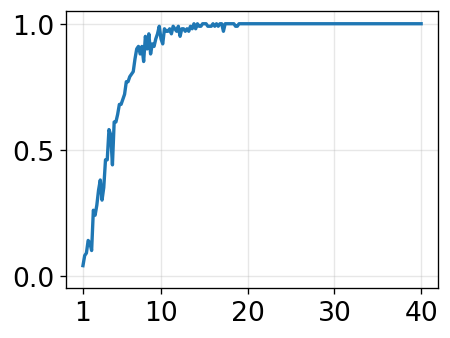

In [30]:
plt.figure(figsize=(4, 3), dpi=120)
plt.plot(ratios, success_rates, linewidth=2)
plt.ylim(-0.05, 1.05)
# plt.xlabel("context_learning_rate_ratio")
# plt.ylabel("success rate")
# plt.title("Sensitivity analysis: context_learning_rate_ratio")
plt.yticks([0,0.5,1])
plt.xticks([1,10,20,30,40])
plt.grid(True, alpha=0.3)
plt.show()

In [26]:
import numpy as np

# --- 1) load existing data ---
data = np.load("context_lr_sensitivity.npz")
ratios_old = data["ratios"]
success_old = data["success_rates"]

# --- 2) compute new range only ---
ratios_new = np.arange(20.2, 40.0 + 1e-9, 0.2)

# run your existing pipeline on the new ratios
# assume: gen_W, train_short_phase, train_long_phase_boundary_Psplit, check_and_print_run are already defined
def run_sensitivity_on_ratios(ratios, repeats=100, debug_print=False):
    num_objects = 6
    context_dim = 2
    hidden_dim = 1000
    hidden_context_dim = 1000
    output_dim = 100

    ground_truth_ranking = [0, 1, 2, 3, 4, 5]

    pairs = [(i, j) for i in range(num_objects) for j in range(num_objects) if i != j]
    labels = [(1 if ground_truth_ranking.index(i) < ground_truth_ranking.index(j) else -1) for i, j in pairs]
    pairs1, labels1 = pairs, labels
    pairs2, labels2 = pairs, labels

    one_hot_vectors1 = torch.eye(num_objects)
    one_hot_vectors2 = torch.eye(num_objects)
    one_hot_context = torch.eye(context_dim)

    eta = 0.1
    num_epochs_short = 10

    boundary_low_ctx0 = 5
    boundary_high_ctx1 = 0
    boundary_label = 1

    num_steps_long = 200

    success_rates = []
    for r in tqdm(ratios,desc='append'):
        successes = 0
        for rep in range(repeats):
            torch.manual_seed(10_000 + int(round(r * 100)) * 100 + rep)
            np.random.seed(20_000 + int(round(r * 100)) * 100 + rep)

            cos = 0.0
            W1 = gen_W(num_objects, hidden_dim, cos)
            W2 = gen_W(num_objects, hidden_dim, cos)
            Wc = gen_W(context_dim, hidden_context_dim, cos)
            P = torch.randn(output_dim, hidden_dim + hidden_context_dim) * 0.0001

            P = train_short_phase(
                W1, W2, Wc, P,
                pairs1, labels1, pairs2, labels2,
                one_hot_vectors1, one_hot_vectors2, one_hot_context,
                eta=eta, num_epochs=num_epochs_short
            )

            P = train_long_phase_boundary_Psplit(
                W1, W2, Wc, P,
                boundary_low_ctx0, boundary_high_ctx1, boundary_label,
                one_hot_vectors1, one_hot_vectors2, one_hot_context,
                eta=eta, context_learning_rate_ratio=float(r),
                num_steps=num_steps_long
            )

            ok = check_and_print_run(
                W1, W2, Wc, P,
                ground_truth_ranking,
                one_hot_vectors1, one_hot_vectors2, one_hot_context,
                boundary_low_ctx0, boundary_high_ctx1,
                ratio=float(r), rep=rep
            )

            if ok:
                successes += 1

        success_rates.append(successes / repeats)

    return np.array(ratios, dtype=float), np.array(success_rates, dtype=float)

ratios_new, success_new = run_sensitivity_on_ratios(ratios_new, repeats=100, debug_print=False)

# --- 3) append + sort + de-duplicate (keep last if duplicates happen) ---
ratios_combined = np.concatenate([ratios_old, ratios_new])
success_combined = np.concatenate([success_old, success_new])

order = np.argsort(ratios_combined)
ratios_combined = ratios_combined[order]
success_combined = success_combined[order]

# de-dup ratios (keep last)
ratios_final = []
success_final = []
i = 0
n = len(ratios_combined)
while i < n:
    r = ratios_combined[i]
    j = i + 1
    while j < n and np.isclose(ratios_combined[j], r, atol=1e-12, rtol=0.0):
        j += 1
    ratios_final.append(ratios_combined[j - 1])
    success_final.append(success_combined[j - 1])
    i = j

ratios_final = np.array(ratios_final, dtype=float)
success_final = np.array(success_final, dtype=float)

# --- 4) overwrite the same npz file with updated arrays ---
np.savez(
    "context_lr_sensitivity_append.npz",
    ratios=ratios_final,
    success_rates=success_final
)

print(f"Saved updated file with {len(ratios_final)} points: {ratios_final[0]:.1f} .. {ratios_final[-1]:.1f}")


append:   0%|          | 0/100 [00:00<?, ?it/s]

Saved updated file with 195 points: 1.0 .. 40.0
